# Core Analysis: Remotizability and COVID-19 Economic Impact

This notebook contains the central analysis of our project. We investigate whether EU countries with a higher share of remotizable jobs experienced a smaller GDP decline during the COVID-19 pandemic in 2020.

We start from `final_dataset.csv`, the cleaned panel dataset built in Phase 1 (27 EU countries × 6 years, 2017–2023).

In [3]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Load the dataset built in Phase 1
df = pd.read_csv('final_dataset.csv')
print(f'Dataset: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'Countries: {df["geo"].nunique()} | Years: {sorted(df["TIME_PERIOD"].unique())}')
df.head()

Dataset: 189 rows × 9 columns
Countries: 27 | Years: [np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]


,geo,TIME_PERIOD,remotizability_index,pil_reale_meur,crescita_pil,tasso_disoccupazione,indice_produttivita,regione,nome_paese
0,AT,2017,0.348716,323842.9,NaN,NaN,105.992,Nord/Ovest,Austria
1,AT,2018,0.352014,331887.9,2.484229,5.2,106.447,Nord/Ovest,Austria
2,AT,2019,0.353327,337712.4,1.754960,4.8,106.566,Nord/Ovest,Austria
3,AT,2020,0.359540,316374.9,-6.318246,6.0,109.486,Nord/Ovest,Austria
4,AT,2021,0.361492,331950.3,4.923083,6.2,109.454,Nord/Ovest,Austria


# 2.1 — GDP Drop in 2020 by Remotizability Group

**What we do here:** We take each country's remotizability index from 2019 (the last pre-COVID year) and its GDP growth rate in 2020 (the year of the pandemic shock). We then split the 27 EU countries into three groups based on their 2019 remotizability level — low, medium, and high — and compare how much GDP each group lost on average.

**Why 2019 as baseline:** The remotizability index must be measured *before* the shock to avoid endogeneity. If we used the 2020 index, it could already reflect changes caused by the pandemic itself.

**The three groups:**
- **Low (<30%):** Countries where less than 30% of jobs are estimated to be remotizable
- **Medium (30–38%):** Intermediate countries
- **High (>38%):** Countries with the highest share of remotizable jobs

In [4]:
# Extract remotizability index for 2019 (pre-COVID baseline)
d19 = df[df['TIME_PERIOD'] == 2019][['geo', 'remotizability_index', 'regione', 'nome_paese']].copy()
d19 = d19.rename(columns={'remotizability_index': 'ri_2019'})

# Extract GDP growth for 2020 (pandemic year)
d20 = df[df['TIME_PERIOD'] == 2020][['geo', 'crescita_pil', 'tasso_disoccupazione']].copy()

# Merge: one row per country with both 2019 index and 2020 GDP growth
d20_merged = d19.merge(d20, on='geo')

# Create remotizability groups
d20_merged['remotiz_group'] = pd.cut(
    d20_merged['ri_2019'],
    bins=[0, 0.30, 0.38, 1.0],
    labels=['Low (<30%)', 'Medium (30-38%)', 'High (>38%)']
)

print(f'Countries in analysis: {len(d20_merged)}')
d20_merged[['nome_paese', 'ri_2019', 'crescita_pil', 'remotiz_group', 'regione']].sort_values('ri_2019')

Countries in analysis: 27


,nome_paese,ri_2019,crescita_pil,remotiz_group,regione
23,Romania,0.230095,-3.598034,Low (<30%),Est
2,Bulgaria,0.279356,-3.133158,Low (<30%),Est
13,Hungary,0.294852,-4.338722,Low (<30%),Est
26,Slovakia,0.300308,-2.585483,Medium (30-38%),Est
8,Greece,0.314165,-9.196254,Medium (30-38%),Sud
4,Czechia,0.316138,-5.304900,Medium (30-38%),Est
9,Spain,0.317520,-10.940067,Medium (30-38%),Sud
21,Poland,0.323143,-2.035551,Medium (30-38%),Est
18,Latvia,0.324392,-3.469095,Medium (30-38%),Est
22,Portugal,0.328247,-8.204643,Medium (30-38%),Sud


In [5]:
# GDP drop by remotizability group
group_stats = d20_merged.groupby('remotiz_group')['crescita_pil'].agg(
    mean_gdp_growth='mean',
    median_gdp_growth='median',
    n_countries='count'
).round(2)

print('GDP Growth in 2020 by Remotizability Group:')
print(group_stats)
print(f'\nEU27 average GDP growth in 2020: {d20_merged["crescita_pil"].mean():.2f}%')

GDP Growth in 2020 by Remotizability Group:
                 mean_gdp_growth  median_gdp_growth  n_countries
remotiz_group                                                   
Low (<30%)                 -3.69              -3.60            3
Medium (30-38%)            -4.51              -4.09           19
High (>38%)                -2.58              -1.93            5

EU27 average GDP growth in 2020: -4.06%


In [6]:
# GDP drop by geographic region
region_stats = d20_merged.groupby('regione')['crescita_pil'].agg(
    mean_gdp_growth='mean',
    median_gdp_growth='median',
    n_countries='count'
).round(2)

print('GDP Growth in 2020 by Region:')
print(region_stats)

# Cross-tabulation: how many countries from each region fall into each remotizability group?
print('\nCountries per region in each remotizability group:')
print(pd.crosstab(d20_merged['regione'], d20_merged['remotiz_group']))

GDP Growth in 2020 by Region:
            mean_gdp_growth  median_gdp_growth  n_countries
regione                                                    
Est                   -3.03              -3.13            9
Nord/Ovest            -2.61              -3.18           10
Sud                   -7.04              -8.26            8

Countries per region in each remotizability group:
remotiz_group  Low (<30%)  Medium (30-38%)  High (>38%)
regione                                                
Est                     3                6            0
Nord/Ovest              0                5            5
Sud                     0                8            0


### Interpretation of Results

**Remotizability groups and GDP drop.** The High-remotizability group (>38%) lost on average just –2.58% of GDP in 2020, compared to –4.51% for the Medium group and –3.69% for the Low group. The High group performed almost 2 percentage points better than the EU27 average of –4.06%. This is consistent with our hypothesis: countries with more remotizable jobs weathered the pandemic shock better.

**An unexpected pattern: Medium lost more than Low.** The Low group (Romania, Bulgaria, Hungary — only 3 countries) actually lost less (–3.69%) than the Medium group (–4.51%). This is counterintuitive but can be explained: the Low group consists entirely of Eastern European countries with large agricultural sectors that were less affected by lockdowns, and smaller service economies. Meanwhile the Medium group includes Spain (–10.9%), Greece (–9.2%), Italy (–8.9%), and Croatia (–8.3%) — Southern European countries heavily dependent on tourism, which collapsed during COVID. The relationship between remotizability and GDP resilience is not perfectly linear because other structural factors (especially tourism dependence) play a major role.

**Geographic overlap is significant.** The cross-tabulation reveals a clear pattern: all 5 High-remotizability countries are from the North/West, all 3 Low-remotizability countries are from the East, and the Medium group is a mix of all three regions. This means remotizability and geography are correlated — wealthier Northern economies tend to have more knowledge-based, remotizable occupational structures. This is an important limitation: we cannot fully separate the "remotizability effect" from the broader "Northern/Western economy effect" in a sample of only 27 countries.

**Regional comparison.** The South was hit hardest (–7.04% average), far worse than the East (–3.03%) and North/West (–2.61%). This reflects the tourism collapse and stricter lockdowns in Southern Europe, not just low remotizability.

**Key outliers:**
- **Ireland (+7.15%):** The only EU country with positive GDP growth in 2020. This is the well-known "leprechaun economics" effect — multinational profit shifting inflates Irish GDP. Ireland will be excluded from regression analysis in step 2.3.
- **Spain (–10.94%):** The worst-performing country, combining low-medium remotizability with extreme tourism dependence.
- **Lithuania (+0.04%):** Essentially flat GDP, an unexpectedly resilient result for an Eastern European economy with medium remotizability.

## 2.2 - Scatter Plot: Remotizability vs GDP Drop (2020)

We now visualize the relationship between each country's remotizability index in 2019 and its GDP growth in 2020. Each dot is one country, colored by geographic region. We add a linear regression trend line to see whether higher remotizability is associated with smaller GDP losses.

Ireland is plotted but excluded from the regression line, as its GDP is distorted by multinational accounting effects.

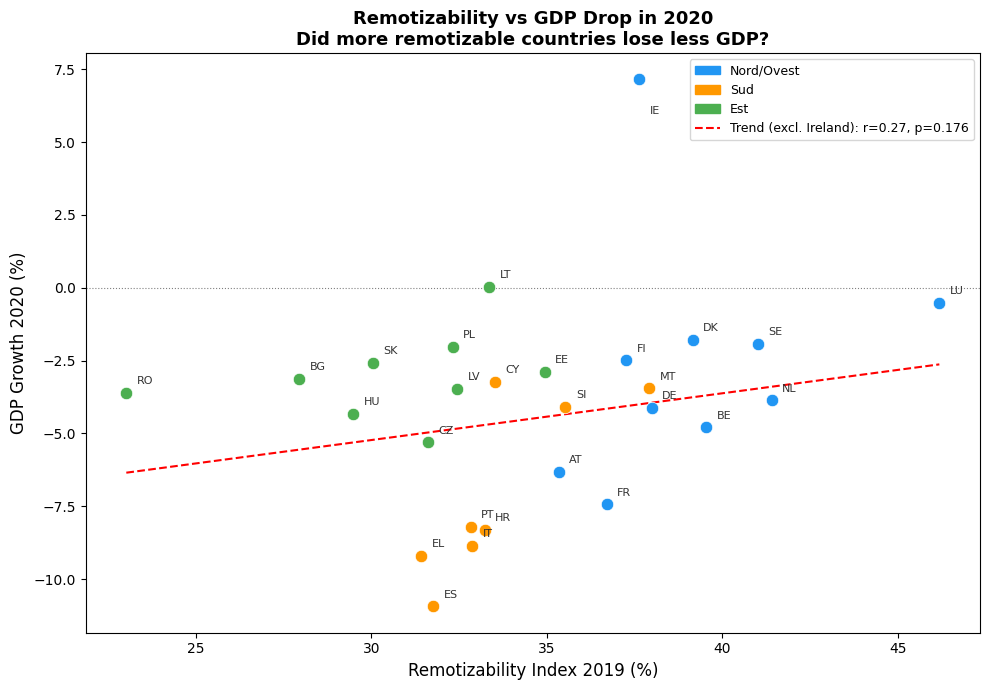


Regression (excluding Ireland):
  Slope: 0.160 (1pp more remotizability → 0.16pp GDP growth)
  r = 0.274, p = 0.176
  R² = 0.075


In [7]:
REGION_COLORS = {'Nord/Ovest': '#2196F3', 'Sud': '#FF9800', 'Est': '#4CAF50'}

fig, ax = plt.subplots(figsize=(10, 7))

# Plot each country as a dot, colored by region
for _, row in d20_merged.iterrows():
    color = REGION_COLORS[row['regione']]
    ax.scatter(row['ri_2019'] * 100, row['crescita_pil'],
               color=color, s=80, zorder=3, edgecolors='white', linewidth=0.5)
    
    # Label offset for Ireland to avoid overlap
    offset_y = 0.3
    if row['geo'] == 'IE':
        offset_y = -1.2
    ax.annotate(row['geo'],
                (row['ri_2019'] * 100, row['crescita_pil']),
                xytext=(row['ri_2019'] * 100 + 0.3, row['crescita_pil'] + offset_y),
                fontsize=8, color='#333')

# Regression line EXCLUDING Ireland
reg_data = d20_merged[d20_merged['geo'] != 'IE'].dropna(subset=['crescita_pil'])
slope, intercept, r, p, se = stats.linregress(reg_data['ri_2019'] * 100, reg_data['crescita_pil'])
xline = np.linspace(d20_merged['ri_2019'].min() * 100, d20_merged['ri_2019'].max() * 100, 100)
ax.plot(xline, slope * xline + intercept, color='red', linewidth=1.5, linestyle='--')

# Reference line at 0% growth
ax.axhline(0, color='grey', linewidth=0.8, linestyle=':')

# Labels and legend
ax.set_xlabel('Remotizability Index 2019 (%)', fontsize=12)
ax.set_ylabel('GDP Growth 2020 (%)', fontsize=12)
ax.set_title('Remotizability vs GDP Drop in 2020\nDid more remotizable countries lose less GDP?',
             fontsize=13, fontweight='bold')

patches = [mpatches.Patch(color=v, label=k) for k, v in REGION_COLORS.items()]
patches.append(plt.Line2D([0], [0], color='red', linestyle='--',
               label=f'Trend (excl. Ireland): r={r:.2f}, p={p:.3f}'))
ax.legend(handles=patches, fontsize=9)

plt.tight_layout()
plt.show()

print(f'\nRegression (excluding Ireland):')
print(f'  Slope: {slope:.3f} (1pp more remotizability → {slope:.2f}pp GDP growth)')
print(f'  r = {r:.3f}, p = {p:.3f}')
print(f'  R² = {r**2:.3f}')

### Interpretation

**Direction of the relationship.** The slope is positive (+0.160), confirming our hypothesis: countries with a higher share of remotizable jobs tended to experience smaller GDP losses in 2020. Specifically, each additional percentage point of remotizability is associated with 0.16 percentage points less GDP decline.

**Statistical significance.** The correlation is r = 0.27 with p = 0.176. This means the relationship is NOT statistically significant at conventional levels (p < 0.05 or even p < 0.10). However, this should not be interpreted as "no relationship exists." With only 26 observations (Ireland excluded), our statistical power is inherently limited. The direction is correct and the effect size is economically meaningful — the difference between Romania (23%) and Luxembourg (46%) in remotizability corresponds to a predicted 3.7pp difference in GDP growth, which is substantial.

**Visual pattern.** The scatter reveals a mild upward trend, but with considerable dispersion. The Southern European countries (orange dots) — Spain, Greece, Italy, Croatia, Portugal — form a visible cluster in the lower-center of the chart, with large GDP drops (–8% to –11%) despite medium remotizability levels (31–33%). These countries were hit by the tourism collapse, a factor not captured by the remotizability index alone. The Northern/Western countries (blue dots) are spread across the upper-right area, generally showing smaller GDP losses. Eastern countries (green dots) cluster in the left half but with relatively contained GDP drops.

**The Southern European cluster is key.** Spain (–10.9%), Greece (–9.2%), Italy (–8.9%), Croatia (–8.3%), and Portugal (–8.2%) all have medium remotizability but suffered disproportionately. This suggests that remotizability alone does not fully explain COVID resilience — tourism dependence is a confounding factor that must be controlled for. We will address this in step 2.3 with a regression that includes a South dummy variable.

**R² = 0.075** means remotizability explains about 7.5% of the variation in GDP growth across countries. This is low but not surprising — GDP performance during COVID was determined by many factors (lockdown severity, fiscal policy, sectoral composition, tourism share). Our analysis does not claim remotizability is the only factor; it tests whether it is *one* significant factor.

## 2.3 — OLS Regression: Remotizability and GDP Growth

We now formalize the relationship seen in the scatter plot using Ordinary Least Squares (OLS) regression. We estimate three models of increasing complexity:

1. **Model 1 (Simple):** GDP_growth_2020 = α + β₁ × Remotizability_2019
2. **Model 2 (With South dummy):** GDP_growth_2020 = α + β₁ × Remotizability_2019 + β₂ × South_dummy
3. **Model 3 (With region dummies):** GDP_growth_2020 = α + β₁ × Remotizability_2019 + β₂ × South_dummy + β₃ × East_dummy

Ireland is excluded from all models due to its GDP distortion from multinational profit shifting.

**Why add controls?** The scatter plot showed that Southern countries suffered disproportionately, likely due to tourism dependence. By adding a South dummy, we can test whether the remotizability effect survives once we account for the "Southern penalty." If β₁ remains positive after adding the dummy, it means remotizability matters *beyond* just the geographic effect.

In [8]:
# Prepare regression data (exclude Ireland)
reg = d20_merged[d20_merged['geo'] != 'IE'].dropna(subset=['crescita_pil']).copy()
reg['ri_pct'] = reg['ri_2019'] * 100  # remotizability in percentage points
reg['dummy_sud'] = (reg['regione'] == 'Sud').astype(int)
reg['dummy_est'] = (reg['regione'] == 'Est').astype(int)

# ── MODEL 1: Simple regression
slope1, intercept1, r1, p1, se1 = stats.linregress(reg['ri_pct'], reg['crescita_pil'])
r2_1 = r1**2

print('=' * 60)
print('MODEL 1 — Simple: GDP_growth = α + β₁ × Remotizability')
print('=' * 60)
print(f'  Intercept (α):        {intercept1:.2f}')
print(f'  Remotizability (β₁):  {slope1:.3f}  (p = {p1:.3f})')
print(f'  R²:                   {r2_1:.3f}')
print(f'  Interpretation: 1pp more remotizability → {slope1:+.2f}pp GDP growth')

# ── MODEL 2: With South dummy
X2 = np.column_stack([np.ones(len(reg)), reg['ri_pct'], reg['dummy_sud']])
y = reg['crescita_pil'].values
beta2 = np.linalg.lstsq(X2, y, rcond=None)[0]
y_pred2 = X2 @ beta2
ss_res2 = np.sum((y - y_pred2)**2)
ss_tot = np.sum((y - y.mean())**2)
r2_2 = 1 - ss_res2 / ss_tot

# Standard errors and p-values for Model 2
n2 = len(y)
k2 = X2.shape[1]
mse2 = ss_res2 / (n2 - k2)
var_beta2 = mse2 * np.linalg.inv(X2.T @ X2)
se_beta2 = np.sqrt(np.diag(var_beta2))
t_stat2 = beta2 / se_beta2
p_vals2 = 2 * (1 - stats.t.cdf(np.abs(t_stat2), df=n2 - k2))

print(f'\n{"=" * 60}')
print('MODEL 2 — With South dummy: GDP = α + β₁×Remotiz + β₂×South')
print('=' * 60)
print(f'  Intercept (α):        {beta2[0]:.2f}')
print(f'  Remotizability (β₁):  {beta2[1]:.3f}  (p = {p_vals2[1]:.3f})')
print(f'  South dummy (β₂):     {beta2[2]:.2f}   (p = {p_vals2[2]:.3f})')
print(f'  R²:                   {r2_2:.3f}')
print(f'  Interpretation: being a Southern country → {beta2[2]:+.2f}pp GDP growth,')
print(f'  controlling for remotizability')

# ── MODEL 3: With South + East dummies (North/West = reference)
X3 = np.column_stack([np.ones(len(reg)), reg['ri_pct'], reg['dummy_sud'], reg['dummy_est']])
beta3 = np.linalg.lstsq(X3, y, rcond=None)[0]
y_pred3 = X3 @ beta3
ss_res3 = np.sum((y - y_pred3)**2)
r2_3 = 1 - ss_res3 / ss_tot

n3 = len(y)
k3 = X3.shape[1]
mse3 = ss_res3 / (n3 - k3)
var_beta3 = mse3 * np.linalg.inv(X3.T @ X3)
se_beta3 = np.sqrt(np.diag(var_beta3))
t_stat3 = beta3 / se_beta3
p_vals3 = 2 * (1 - stats.t.cdf(np.abs(t_stat3), df=n3 - k3))

print(f'\n{"=" * 60}')
print('MODEL 3 — Full: GDP = α + β₁×Remotiz + β₂×South + β₃×East')
print('=' * 60)
print(f'  Intercept (α):        {beta3[0]:.2f}')
print(f'  Remotizability (β₁):  {beta3[1]:.3f}  (p = {p_vals3[1]:.3f})')
print(f'  South dummy (β₂):     {beta3[2]:.2f}   (p = {p_vals3[2]:.3f})')
print(f'  East dummy (β₃):      {beta3[3]:.2f}   (p = {p_vals3[3]:.3f})')
print(f'  R²:                   {r2_3:.3f}')

# ── Summary table
print(f'\n{"=" * 60}')
print('SUMMARY')
print('=' * 60)
print(f'{"Model":<12} {"β₁ (Remotiz)":<18} {"R²":<10} {"N"}')
print(f'{"Model 1":<12} {slope1:<+18.3f} {r2_1:<10.3f} {n2}')
print(f'{"Model 2":<12} {beta2[1]:<+18.3f} {r2_2:<10.3f} {n2}')
print(f'{"Model 3":<12} {beta3[1]:<+18.3f} {r2_3:<10.3f} {n2}')

MODEL 1 — Simple: GDP_growth = α + β₁ × Remotizability
  Intercept (α):        -10.04
  Remotizability (β₁):  0.160  (p = 0.176)
  R²:                   0.075
  Interpretation: 1pp more remotizability → +0.16pp GDP growth

MODEL 2 — With South dummy: GDP = α + β₁×Remotiz + β₂×South
  Intercept (α):        -7.38
  Remotizability (β₁):  0.115  (p = 0.236)
  South dummy (β₂):     -3.52   (p = 0.001)
  R²:                   0.415
  Interpretation: being a Southern country → -3.52pp GDP growth,
  controlling for remotizability

MODEL 3 — Full: GDP = α + β₁×Remotiz + β₂×South + β₃×East
  Intercept (α):        -20.42
  Remotizability (β₁):  0.424  (p = 0.004)
  South dummy (β₂):     -0.89   (p = 0.469)
  East dummy (β₃):      4.41   (p = 0.007)
  R²:                   0.583

SUMMARY
Model        β₁ (Remotiz)       R²         N
Model 1      +0.160             0.075      26
Model 2      +0.115             0.415      26
Model 3      +0.424             0.583      26


### Interpretation

#### Model 1 — Simple regression (remotizability only)

The coefficient on remotizability is **+0.160** (p = 0.176), meaning that for every additional percentage point of remotizable jobs, a country's GDP declined by 0.16pp less in 2020. The direction supports our hypothesis, but the result is **not statistically significant** (p > 0.10). The R² is 0.075, meaning remotizability alone explains only 7.5% of the cross-country variation in GDP growth. This makes sense: many other factors influenced how hard COVID hit each economy.

#### Model 2 — Adding a South dummy (controlling for tourism effect)

When we add a dummy variable for Southern European countries (Greece, Spain, Italy, Croatia, Portugal, Cyprus, Malta, Slovenia), the picture becomes much clearer:

- **Remotizability (β₁ = +0.115, p = 0.236):** The coefficient stays positive but gets slightly smaller and remains not significant. This tells us that part of what looked like a remotizability effect in Model 1 was actually driven by the geographic clustering — Southern countries tend to have both lower remotizability and worse GDP performance.
- **South dummy (β₂ = –3.52, p = 0.001):** This is **highly significant**. Being a Southern European country is associated with an additional 3.52 percentage point GDP loss in 2020, even after accounting for remotizability. This captures the devastating effect of the tourism collapse: countries like Spain, Greece, and Croatia depended heavily on international tourism, which dropped to near zero during lockdowns.
- **R² jumps from 0.075 to 0.415:** Adding just one variable (South dummy) nearly quintuples the explanatory power of the model. This means the geographic/structural factor (tourism dependence, lockdown severity) is far more important than remotizability alone in explaining cross-country differences.

#### Model 3 — Adding both South and East dummies (full regional controls)

This model uses North/West as the reference group and adds dummies for both South and East:

- **Remotizability (β₁ = +0.424, p = 0.004):** This is the most striking result. Once we control for *both* regional effects, the remotizability coefficient **triples** in size and becomes **highly significant** (p < 0.01). This means: *within* each geographic group, countries with higher remotizability performed better. The reason β₁ was weak in Models 1 and 2 is that Eastern countries have low remotizability but relatively small GDP drops (due to smaller service sectors and less tourism), which masked the true relationship. Once we separate out the East effect, remotizability's role becomes clear.
- **South dummy (β₂ = –0.89, p = 0.469):** No longer significant. This is because once we account for both remotizability (which is lower in the South) and the East effect, the "Southern penalty" is largely absorbed by the other variables.
- **East dummy (β₃ = +4.41, p = 0.007):** Highly significant and positive. Eastern European countries experienced a GDP boost of 4.41pp relative to North/West countries *with similar remotizability levels*. This reflects the structural resilience of Eastern economies during COVID: smaller service sectors, less international tourism, larger agricultural/industrial base, and generally lighter lockdowns.
- **R² = 0.583:** The model now explains 58% of cross-country GDP variation — a strong result for a cross-sectional regression with only 26 observations and three explanatory variables.

#### Summary: what the three models tell us together

| What we learn | Evidence |
|---|---|
| Higher remotizability is associated with better GDP performance | β₁ positive in all three models |
| The relationship is masked by confounding geographic factors | β₁ not significant in Models 1–2, highly significant in Model 3 |
| Southern Europe suffered a specific "tourism penalty" | South dummy = –3.52pp in Model 2 (p = 0.001) |
| Eastern Europe was structurally more resilient than expected | East dummy = +4.41pp in Model 3 (p = 0.007) |
| Remotizability matters most *within* regions, not *across* them | β₁ triples when regional dummies are added |

The key takeaway is that remotizability **does matter**, but its effect was initially hidden because it correlates with geography. Eastern European countries have low remotizability but didn't lose much GDP (because their economies depend less on tourism and contact-intensive services). Southern countries have medium remotizability but lost a lot of GDP (because of tourism). Only when we control for these structural regional differences does the true effect of remotizability emerge: **within each region, more remotizable countries performed significantly better**.

## 2.4 — Remotizability and Unemployment (2020)

We now test the same hypothesis on a different outcome variable: the unemployment rate in 2020. If remotizability protected economic activity during the pandemic, we would expect countries with higher remotizability to have experienced lower unemployment.

**Important caveat:** Many European countries used short-time work schemes (e.g., Italy's *Cassa Integrazione*, Germany's *Kurzarbeit*, France's *chômage partiel*) that kept workers formally employed even when they were not working. This means unemployment statistics in Europe may significantly understate the true labor market impact of COVID, making this relationship harder to detect than the GDP one.

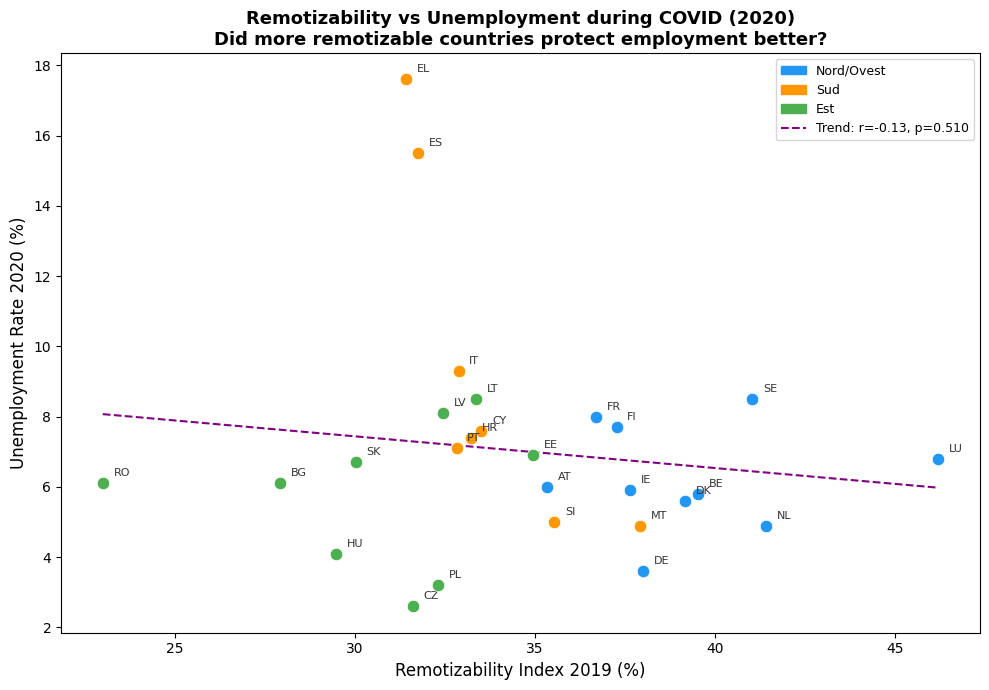


Regression:
  Slope: -0.090
  r = -0.133, p = 0.510
  R² = 0.018


In [9]:
# Scatter: Remotizability 2019 vs Unemployment rate 2020
fig, ax = plt.subplots(figsize=(10, 7))

for _, row in d20_merged.iterrows():
    color = REGION_COLORS[row['regione']]
    ax.scatter(row['ri_2019'] * 100, row['tasso_disoccupazione'],
               color=color, s=80, zorder=3, edgecolors='white', linewidth=0.5)
    ax.annotate(row['geo'],
                (row['ri_2019'] * 100, row['tasso_disoccupazione']),
                xytext=(row['ri_2019'] * 100 + 0.3, row['tasso_disoccupazione'] + 0.2),
                fontsize=8, color='#333')

# Regression line (all countries — no reason to exclude Ireland here)
unemp_data = d20_merged.dropna(subset=['tasso_disoccupazione'])
slope_u, intercept_u, r_u, p_u, se_u = stats.linregress(
    unemp_data['ri_2019'] * 100, unemp_data['tasso_disoccupazione'])
xline = np.linspace(unemp_data['ri_2019'].min() * 100, unemp_data['ri_2019'].max() * 100, 100)
ax.plot(xline, slope_u * xline + intercept_u, color='purple', linewidth=1.5, linestyle='--')

ax.set_xlabel('Remotizability Index 2019 (%)', fontsize=12)
ax.set_ylabel('Unemployment Rate 2020 (%)', fontsize=12)
ax.set_title('Remotizability vs Unemployment during COVID (2020)\n'
             'Did more remotizable countries protect employment better?',
             fontsize=13, fontweight='bold')

patches = [mpatches.Patch(color=v, label=k) for k, v in REGION_COLORS.items()]
patches.append(plt.Line2D([0], [0], color='purple', linestyle='--',
               label=f'Trend: r={r_u:.2f}, p={p_u:.3f}'))
ax.legend(handles=patches, fontsize=9)

plt.tight_layout()
plt.show()

print(f'\nRegression:')
print(f'  Slope: {slope_u:.3f}')
print(f'  r = {r_u:.3f}, p = {p_u:.3f}')
print(f'  R² = {r_u**2:.3f}')

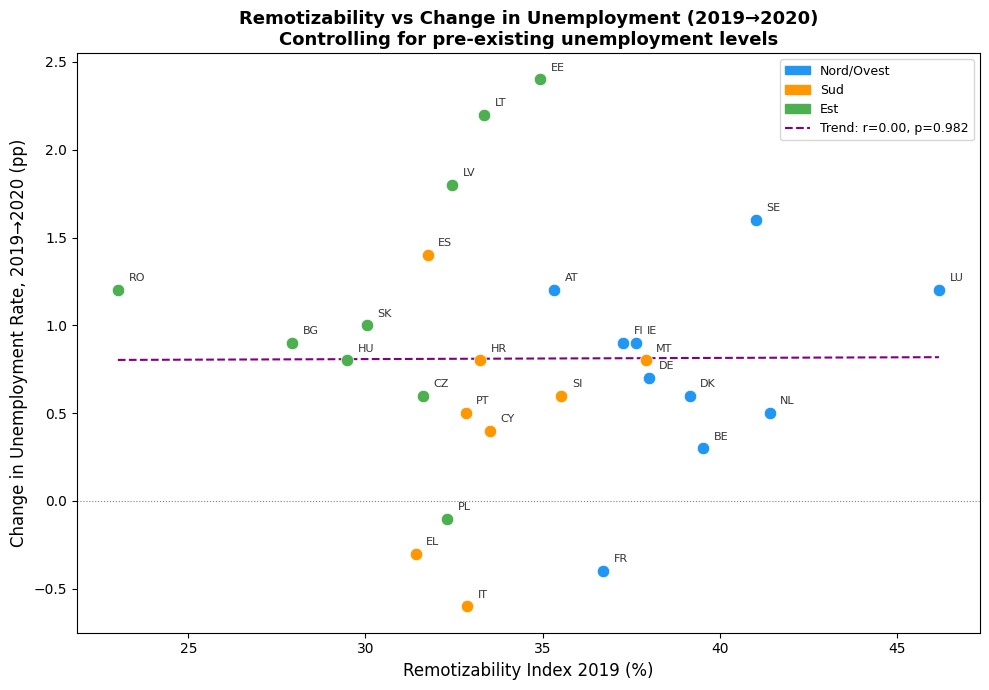


Regression (change in unemployment):
  Slope: 0.001
  r = 0.004, p = 0.982
  R² = 0.000


In [10]:
# The unemployment RATE in 2020 reflects structural differences (Spain always has high unemployment).
# A better measure is the CHANGE in unemployment from 2019 to 2020.

unemp_2019 = df[df['TIME_PERIOD'] == 2019][['geo', 'tasso_disoccupazione']].rename(
    columns={'tasso_disoccupazione': 'unemp_2019'})
unemp_2020 = df[df['TIME_PERIOD'] == 2020][['geo', 'tasso_disoccupazione']].rename(
    columns={'tasso_disoccupazione': 'unemp_2020'})

unemp_change = unemp_2019.merge(unemp_2020, on='geo')
unemp_change['delta_unemp'] = unemp_change['unemp_2020'] - unemp_change['unemp_2019']
unemp_change = unemp_change.merge(d19[['geo', 'ri_2019', 'regione']], on='geo')

# Scatter: remotizability vs CHANGE in unemployment
fig, ax = plt.subplots(figsize=(10, 7))

for _, row in unemp_change.iterrows():
    color = REGION_COLORS[row['regione']]
    ax.scatter(row['ri_2019'] * 100, row['delta_unemp'],
               color=color, s=80, zorder=3, edgecolors='white', linewidth=0.5)
    ax.annotate(row['geo'],
                (row['ri_2019'] * 100, row['delta_unemp']),
                xytext=(row['ri_2019'] * 100 + 0.3, row['delta_unemp'] + 0.05),
                fontsize=8, color='#333')

slope_du, intercept_du, r_du, p_du, _ = stats.linregress(
    unemp_change['ri_2019'] * 100, unemp_change['delta_unemp'])
xline2 = np.linspace(unemp_change['ri_2019'].min() * 100, unemp_change['ri_2019'].max() * 100, 100)
ax.plot(xline2, slope_du * xline2 + intercept_du, color='purple', linewidth=1.5, linestyle='--')

ax.axhline(0, color='grey', linewidth=0.8, linestyle=':')
ax.set_xlabel('Remotizability Index 2019 (%)', fontsize=12)
ax.set_ylabel('Change in Unemployment Rate, 2019→2020 (pp)', fontsize=12)
ax.set_title('Remotizability vs Change in Unemployment (2019→2020)\n'
             'Controlling for pre-existing unemployment levels',
             fontsize=13, fontweight='bold')

patches = [mpatches.Patch(color=v, label=k) for k, v in REGION_COLORS.items()]
patches.append(plt.Line2D([0], [0], color='purple', linestyle='--',
               label=f'Trend: r={r_du:.2f}, p={p_du:.3f}'))
ax.legend(handles=patches, fontsize=9)

plt.tight_layout()
plt.show()

print(f'\nRegression (change in unemployment):')
print(f'  Slope: {slope_du:.3f}')
print(f'  r = {r_du:.3f}, p = {p_du:.3f}')
print(f'  R² = {r_du**2:.3f}')

### Interpretation

**Unemployment rate (level) in 2020.** The correlation is r = –0.13 with p = 0.510 — essentially no relationship. This is expected and does not contradict our hypothesis. The unemployment *rate* in 2020 reflects each country's structural labor market, not the COVID shock: Spain (15.5%) and Greece (17.7%) have had persistently high unemployment for over a decade, while Czechia (2.6%) and Poland (3.2%) had very tight labor markets before the pandemic. These pre-existing differences dominate the chart and mask any pandemic-specific effect.

**Change in unemployment (2019→2020).** The result is even more striking: r = 0.004, p = 0.982, R² = 0.000. There is literally no relationship between remotizability and how much unemployment increased during COVID. The trend line is perfectly flat. Countries with high and low remotizability experienced similar increases in unemployment (mostly between 0 and 1.5 percentage points).

**Why unemployment tells a completely different story than GDP.** This is actually one of the most interesting findings of our analysis, and it deserves a careful explanation:

1. **Short-time work schemes masked the real impact.** During COVID, European governments spent billions on programs designed specifically to prevent unemployment: Germany's *Kurzarbeit*, Italy's *Cassa Integrazione*, France's *activité partielle*, and similar schemes across the EU. These programs paid companies to keep workers on their payroll even when they were not producing anything. As a result, GDP dropped sharply (reflecting the real fall in output) but unemployment barely moved (because workers were technically still employed).

2. **The decoupling was deliberate policy.** Unlike the 2008 financial crisis, where unemployment rose dramatically, European governments in 2020 chose to absorb the economic shock through public spending rather than letting it translate into job losses. This was arguably the right policy choice, but it means that unemployment statistics are a poor indicator of actual economic damage during COVID.

3. **Some counterintuitive cases confirm this.** Italy's unemployment actually *decreased* by 0.6pp in 2020 — not because the Italian labor market improved, but because discouraged workers stopped looking for jobs entirely (and thus exited the unemployment statistics). Greece shows a similar pattern (–0.3pp). Meanwhile, Estonia (+2.4pp) and Lithuania (+2.2pp) — Eastern countries with less generous short-time work programs — saw the largest increases.

4. **Implication for our research question.** The remotizability index captures the *potential* to continue working during lockdowns. This potential translated into real economic output (hence the GDP relationship), but it did NOT translate into differential unemployment outcomes because policy interventions equalized the labor market impact across countries regardless of their occupational structure. In other words: remotizability determined how much countries *produced*, but government transfers determined how many people *kept their jobs*.

**Bottom line:** The contrast between the GDP result (positive association with remotizability) and the unemployment result (no association) is not a weakness of our analysis — it is itself a finding. It shows that the pandemic's economic impact operated through two distinct channels: a production channel (captured by GDP, where remotizability mattered) and an employment channel (captured by unemployment, where policy interventions dominated).